# Raw Attention Vector Analysis from MongoDB

This notebook loads previously saved scans from MongoDB (via `NSBackend`) and
analyses the **raw last-token activation vector** at every `SelfAttention.o` layer —
without applying the logit-lens unembedding matrix.

Each vector is 1,024-dimensional (the model's hidden size), representing the
internal state of the last token in the sequence as it passes through each
attention layer. All divergence, stabilization, and separation metrics from
`logit_lens_from_mongo.ipynb` are reproduced here on these raw vectors.

## Cell 1 — Imports & sys.path

In [ ]:
import sys, os

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import torch

from neuralsignal.backend.ns_backend import NSBackend

print(f"torch version : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

## Cell 2 — Config (edit these values before running)

- `APPLICATION_NAME` / `SUB_APPLICATION_NAME`: must match what was used when the scans were saved.
- `SCAN_ID_1` / `SCAN_ID_2`: MongoDB ObjectId strings for the two scans to compare.
- `LABEL_1` / `LABEL_2`: short names shown in plot titles and table headers.
- `MODEL_NAME`: must match the judge model that generated the scans.

In [ ]:
APPLICATION_NAME     = "redis"
SUB_APPLICATION_NAME = "quora_duplicates_t5_large"

SCAN_ID_1 = "66fc602ade4a4bd5fec2a371"   # MongoDB ObjectId string
SCAN_ID_2 = "66fc602dde4a4bd5fec2a4ac"

LABEL_1 = "Scan A"
LABEL_2 = "Scan B"

DEVICE = "cpu"

## Cell 3 — Connect to backend & load both scans

The backend config is pulled from the `sdk_config` singleton and
`scan_cache_directory` is patched to `tempfile.gettempdir()` in case the YAML
points to a drive letter that doesn't exist locally.

In [3]:
import tempfile
from neuralsignal.core.modules.neuralsignal_config import sdk_config

backend_cfg = sdk_config.get_backend_config()
backend_cfg["scan_cache_directory"] = tempfile.gettempdir()

cfg = {
    "application_name": APPLICATION_NAME,
    "sub_application_name": SUB_APPLICATION_NAME,
    "backend_config": backend_cfg,
}
be = NSBackend(cfg)

scan1 = be.load_scan(SCAN_ID_1)
scan2 = be.load_scan(SCAN_ID_2)

for label, scan in [(LABEL_1, scan1), (LABEL_2, scan2)]:
    print(f"[{label}]")
    print(f"  input  : {scan['input'][:120]}")
    print(f"  output : {scan['output']}")
    print(f"  layers : {len(scan['layer_order'])}")
    print()

[Scan A]
  input  : 
  output : 
  layers : 553

[Scan B]
  input  : 
  output : 
  layers : 553



## Cell 4 — Validate both scans

Checks that each scan contains `SelfAttention.o` layers with the full hidden
dimension. Raises early if a scan was saved with zone compression (`zone_size > 1`).

In [4]:
def validate_scan(scan, label):
    sa_layer_id = next(
        (lid for lid in scan["layer_order"]
         if "SelfAttention.o" in scan["layer_id_to_name"][lid]),
        None,
    )
    if sa_layer_id is None:
        raise ValueError(f"[{label}] No SelfAttention.o layers found.")
    t = scan["outputs"][sa_layer_id]
    hidden_dim = t.shape[-1]
    if hidden_dim < 512:
        raise ValueError(
            f"[{label}] hidden_dim={hidden_dim}. Scan was saved with zone compression "
            "(zone_size_by_layer > 1). Re-capture with zone_size_by_layer: {{default: 1}}."
        )
    print(f"[{label}]  first SelfAttention.o: {scan['layer_id_to_name'][sa_layer_id]}")
    print(f"         tensor shape          : {t.shape}  — OK")

validate_scan(scan1, LABEL_1)
validate_scan(scan2, LABEL_2)

[Scan A]  first SelfAttention.o: encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
         tensor shape          : torch.Size([121, 1024])  — OK
[Scan B]  first SelfAttention.o: encoder.T5Block.T5LayerSelfAttention.SelfAttention.o
         tensor shape          : torch.Size([141, 1024])  — OK


## Cell 5 — Build raw activation vectors for both scans

`build_raw_vectors(scan)` iterates `layer_order`, keeps only `SelfAttention.o`
layers, and takes the last-token slice directly — no unembedding applied.
Each vector is shape `(hidden_dim,)` = `(1024,)` for flan-t5-large.

In [ ]:
def build_logit_vectors(scan):
    """
    Extract the raw last-token activation vector at every SelfAttention.o layer.
    Returns a list of {"layer_name": str, "logit_vector": Tensor(hidden_dim,)}.
    The key is named 'logit_vector' for compatibility with all downstream analysis cells.
    """
    layer_id_to_name = scan["layer_id_to_name"]
    vectors = []
    for layer_id in scan["layer_order"]:
        layer_name = layer_id_to_name[layer_id]
        if "SelfAttention.o" not in layer_name:
            continue
        tensor = scan["outputs"][layer_id]   # shape: (seq_len, hidden_dim)
        last_token = tensor[-1, :].float()   # shape: (hidden_dim,)
        vectors.append({"layer_name": layer_name, "logit_vector": last_token})
    return vectors

logit_vectors_1 = build_logit_vectors(scan1)
logit_vectors_2 = build_logit_vectors(scan2)

print(f"[{LABEL_1}]  {len(logit_vectors_1)} SelfAttention.o layers, "
      f"vector dim: {logit_vectors_1[0]['logit_vector'].shape[0]}")
print(f"[{LABEL_2}]  {len(logit_vectors_2)} SelfAttention.o layers, "
      f"vector dim: {logit_vectors_2[0]['logit_vector'].shape[0]}")

## Cell 6 — Raw vector stabilization across layers

Two metrics measured against the **final layer's raw activation vector**:

- **Angle (°)** — `arccos(cosine_similarity)`: 0° means identical direction, 90° means orthogonal.  
  Drops toward 0 as the model's hidden state "commits" to its final representation.
- **L2 distance** — Euclidean distance in 1,024-dimensional hidden space.  
  Measures magnitude of remaining drift, not just direction.

Both are plotted on a shared x-axis (layer index, encoder layers first).

In [ ]:
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def stabilization_metrics(logit_vectors):
    """Angle (deg) and L2 distance of each layer vs the final layer."""
    ref = logit_vectors[-1]["logit_vector"].float()
    angles, l2s, labels = [], [], []
    for entry in logit_vectors:
        v = entry["logit_vector"].float()
        cos = torch.dot(v, ref) / (v.norm() * ref.norm())
        angles.append(math.degrees(math.acos(cos.clamp(-1, 1).item())))
        l2s.append((v - ref).norm().item())
        labels.append(entry["layer_name"])
    boundary = next(
        (i for i, e in enumerate(logit_vectors) if e["layer_name"].startswith("decoder.")),
        None,
    )
    return angles, l2s, labels, boundary

def plot_stabilization(ax_angle, ax_l2, logit_vectors, label):
    angles, l2s, labels, boundary = stabilization_metrics(logit_vectors)
    x = list(range(len(logit_vectors)))

    ax_angle.plot(x, angles, marker="o", markersize=3, color="steelblue", linewidth=1.5)
    ax_angle.set_ylabel("Angle to final layer (°)")
    ax_angle.set_title(label, fontsize=10)
    ax_angle.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_angle.grid(axis="y", linestyle="--", alpha=0.4)

    ax_l2.plot(x, l2s, marker="s", markersize=3, color="darkorange", linewidth=1.5)
    ax_l2.set_ylabel("L2 distance to final layer")
    ax_l2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_l2.grid(axis="y", linestyle="--", alpha=0.4)

    tick_step = max(1, len(x) // 10)
    ax_l2.set_xticks(x[::tick_step])
    ax_l2.set_xticklabels(labels[::tick_step], rotation=45, ha="right", fontsize=6)
    ax_l2.set_xlabel("Layer (capture order)")

    if boundary is not None:
        for ax in (ax_angle, ax_l2):
            ax.axvline(boundary - 0.5, color="gray", linestyle=":", linewidth=1.2)
        ax_angle.text(boundary - 0.4, ax_angle.get_ylim()[1] * 0.95,
                      "enc|dec", fontsize=6, color="gray", va="top")

fig, axes = plt.subplots(2, 2, figsize=(18, 7), sharex="col")
fig.suptitle("Raw vector stabilization toward final layer", fontsize=13)

plot_stabilization(axes[0, 0], axes[1, 0], logit_vectors_1, LABEL_1)
plot_stabilization(axes[0, 1], axes[1, 1], logit_vectors_2, LABEL_2)

plt.tight_layout()
plt.show()

## Cell 9 — Layer-to-layer delta (consecutive comparison)

Same two metrics, but now each layer is compared to its **immediate predecessor**
rather than the final layer. This shows *where* the representation is still changing
rapidly, rather than how far it still is from convergence.

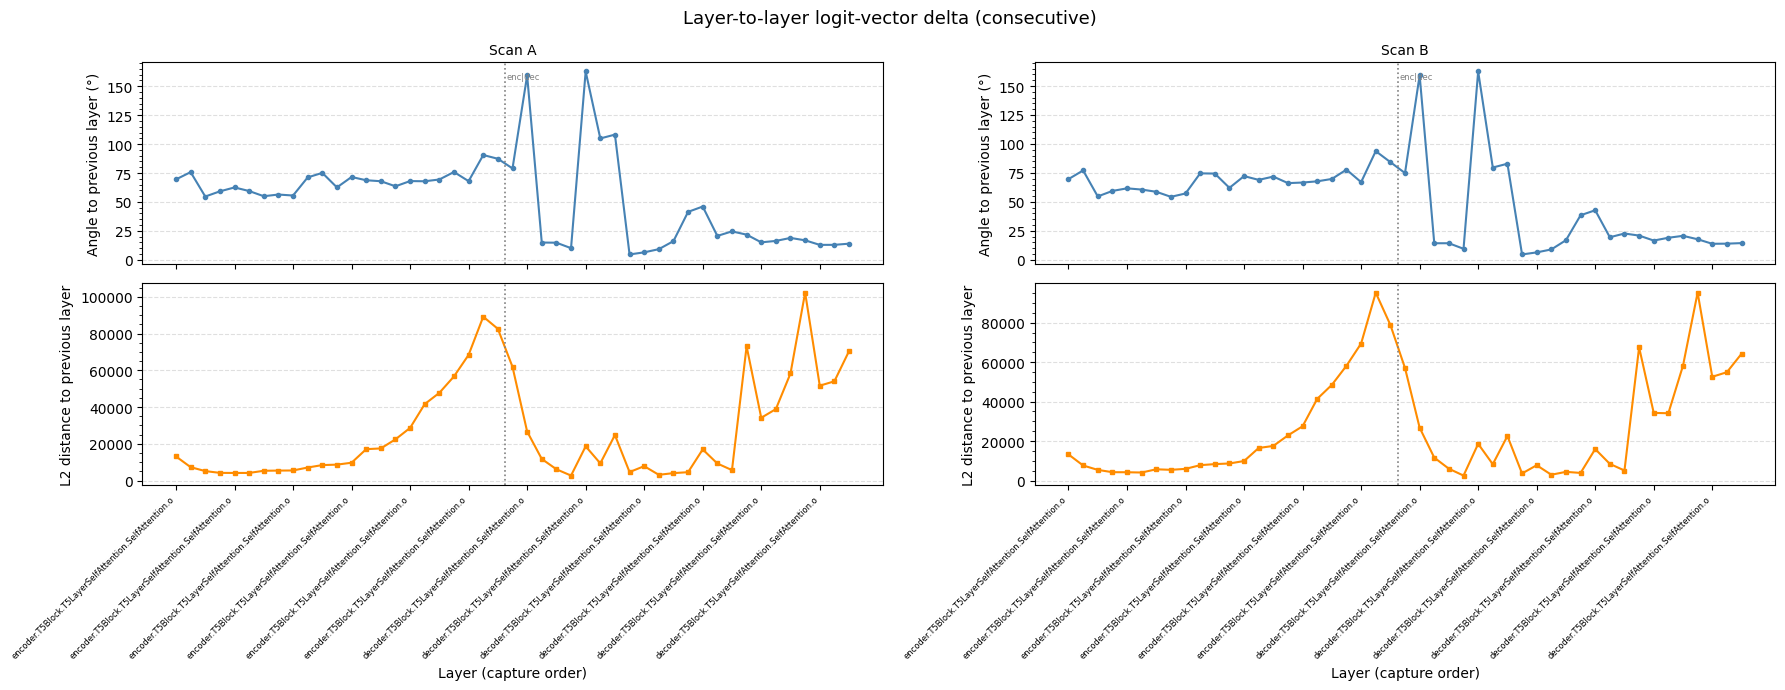

In [9]:
def delta_metrics(logit_vectors):
    """Angle (deg) and L2 distance between each consecutive pair of layers."""
    angles, l2s, labels = [], [], []
    for i in range(1, len(logit_vectors)):
        prev = logit_vectors[i - 1]["logit_vector"].float()
        curr = logit_vectors[i]["logit_vector"].float()
        cos = torch.dot(curr, prev) / (curr.norm() * prev.norm())
        angles.append(math.degrees(math.acos(cos.clamp(-1, 1).item())))
        l2s.append((curr - prev).norm().item())
        labels.append(logit_vectors[i]["layer_name"])
    boundary = next(
        (i for i, e in enumerate(logit_vectors[1:]) if e["layer_name"].startswith("decoder.")),
        None,
    )
    return angles, l2s, labels, boundary

def plot_delta(ax_angle, ax_l2, logit_vectors, label):
    angles, l2s, labels, boundary = delta_metrics(logit_vectors)
    x = list(range(len(labels)))

    ax_angle.plot(x, angles, marker="o", markersize=3, color="steelblue", linewidth=1.5)
    ax_angle.set_ylabel("Angle to previous layer (°)")
    ax_angle.set_title(label, fontsize=10)
    ax_angle.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_angle.grid(axis="y", linestyle="--", alpha=0.4)

    ax_l2.plot(x, l2s, marker="s", markersize=3, color="darkorange", linewidth=1.5)
    ax_l2.set_ylabel("L2 distance to previous layer")
    ax_l2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_l2.grid(axis="y", linestyle="--", alpha=0.4)

    tick_step = max(1, len(x) // 10)
    ax_l2.set_xticks(x[::tick_step])
    ax_l2.set_xticklabels(labels[::tick_step], rotation=45, ha="right", fontsize=6)
    ax_l2.set_xlabel("Layer (capture order)")

    if boundary is not None:
        for ax in (ax_angle, ax_l2):
            ax.axvline(boundary - 0.5, color="gray", linestyle=":", linewidth=1.2)
        ax_angle.text(boundary - 0.4, ax_angle.get_ylim()[1] * 0.95,
                      "enc|dec", fontsize=6, color="gray", va="top")

fig, axes = plt.subplots(2, 2, figsize=(18, 7), sharex="col")
fig.suptitle("Layer-to-layer logit-vector delta (consecutive)", fontsize=13)

plot_delta(axes[0, 0], axes[1, 0], logit_vectors_1, LABEL_1)
plot_delta(axes[0, 1], axes[1, 1], logit_vectors_2, LABEL_2)

plt.tight_layout()
plt.show()

---
## Group comparison: correct False vs incorrect True (ground_truth = 0)

Load 20 scans from each group, build per-scan logit vectors, then average the
stabilization metrics across scans and plot both groups overlaid on the same axes.

| Group | ground_truth | decoded_output | Meaning |
|-------|-------------|----------------|---------|
| **False** (blue) | 0 | starts with "Fal" | model correctly said False |
| **True** (red) | 0 | starts with "True" | model incorrectly said True (hallucination) |

The shaded band is ±1 std across the 20 scans.

In [10]:
GROUP_SIZE = 200   # scans to load per group

FILTER_FALSE = {"ground_truth": "0", "decoded_output": "Fal"}
FILTER_TRUE  = {"ground_truth": "0", "decoded_output": "True"}

def load_group(be, mongo_filter, n):
    """Load and deserialize up to n scans matching mongo_filter."""
    cursor = be.query(mongo_filter).limit(n)
    scans = []
    for doc in cursor:
        try:
            scans.append(be.deserialize_scan(doc))
        except Exception as e:
            print(f"  skipping scan {doc.get('_id')}: {e}")
    return scans

print("Loading group: ground_truth='0', decoded_output='Fal' ...")
group_false = load_group(be, FILTER_FALSE, GROUP_SIZE)
print(f"  loaded {len(group_false)} scans")

print("Loading group: ground_truth='0', decoded_output='True' ...")
group_true = load_group(be, FILTER_TRUE, GROUP_SIZE)
print(f"  loaded {len(group_true)} scans")

Loading group: ground_truth='0', decoded_output='Fal' ...
  loaded 200 scans
Loading group: ground_truth='0', decoded_output='True' ...
  loaded 200 scans


In [11]:
def build_group_logit_vectors(scans, expected_layers=None):
    """
    Build logit vectors for every scan in the group.
    Scans whose SelfAttention.o layer count doesn't match expected_layers are skipped.
    Returns (list_of_logit_vectors, n_layers, layer_labels, boundary_index).
    """
    all_vectors = []
    for scan in scans:
        try:
            lv = build_logit_vectors(scan)
        except Exception as e:
            print(f"  skipping {scan.get('_id')}: {e}")
            continue
        if expected_layers is not None and len(lv) != expected_layers:
            print(f"  skipping {scan.get('_id')}: expected {expected_layers} layers, got {len(lv)}")
            continue
        all_vectors.append(lv)

    if not all_vectors:
        raise ValueError("No valid scans in group.")

    # Use layer count from the first valid scan as the expected count for the rest
    n_layers = len(all_vectors[0])
    labels = [e["layer_name"] for e in all_vectors[0]]
    boundary = next(
        (i for i, name in enumerate(labels) if name.startswith("decoder.")), None
    )
    return all_vectors, n_layers, labels, boundary

# Determine expected layer count from whichever group loads first
lv_false, n_layers, layer_labels, boundary = build_group_logit_vectors(group_false)
lv_true,  _,        _,            _        = build_group_logit_vectors(group_true, expected_layers=n_layers)

print(f"Group False : {len(lv_false)} valid scans, {n_layers} SelfAttention.o layers each")
print(f"Group True  : {len(lv_true)} valid scans")

Group False : 200 valid scans, 48 SelfAttention.o layers each
Group True  : 200 valid scans


In [12]:
import numpy as np

def group_stabilization_metrics(all_logit_vectors):
    """
    For each layer, compute angle-to-final and L2-to-final for every scan,
    then return mean and std arrays of shape (n_layers,).
    Each scan uses its own final layer as the reference, so the metrics are
    comparable across scans with different inputs.
    """
    n_layers = len(all_logit_vectors[0])
    per_layer_angles = [[] for _ in range(n_layers)]
    per_layer_l2s    = [[] for _ in range(n_layers)]

    for logit_vectors in all_logit_vectors:
        ref = logit_vectors[-1]["logit_vector"].float()
        for i, entry in enumerate(logit_vectors):
            v = entry["logit_vector"].float()
            cos = torch.dot(v, ref) / (v.norm() * ref.norm())
            per_layer_angles[i].append(math.degrees(math.acos(cos.clamp(-1, 1).item())))
            per_layer_l2s[i].append((v - ref).norm().item())

    mean_angles = np.array([np.mean(a) for a in per_layer_angles])
    std_angles  = np.array([np.std(a)  for a in per_layer_angles])
    mean_l2s    = np.array([np.mean(l) for l in per_layer_l2s])
    std_l2s     = np.array([np.std(l)  for l in per_layer_l2s])
    return mean_angles, std_angles, mean_l2s, std_l2s

def group_delta_metrics(all_logit_vectors):
    """
    For each consecutive layer pair, compute angle and L2 distance,
    then return mean and std arrays of shape (n_layers - 1,).
    """
    n_layers = len(all_logit_vectors[0])
    per_layer_angles = [[] for _ in range(n_layers - 1)]
    per_layer_l2s    = [[] for _ in range(n_layers - 1)]

    for logit_vectors in all_logit_vectors:
        for i in range(1, n_layers):
            prev = logit_vectors[i - 1]["logit_vector"].float()
            curr = logit_vectors[i]["logit_vector"].float()
            cos = torch.dot(curr, prev) / (curr.norm() * prev.norm())
            per_layer_angles[i - 1].append(math.degrees(math.acos(cos.clamp(-1, 1).item())))
            per_layer_l2s[i - 1].append((curr - prev).norm().item())

    mean_angles = np.array([np.mean(a) for a in per_layer_angles])
    std_angles  = np.array([np.std(a)  for a in per_layer_angles])
    mean_l2s    = np.array([np.mean(l) for l in per_layer_l2s])
    std_l2s     = np.array([np.std(l)  for l in per_layer_l2s])
    return mean_angles, std_angles, mean_l2s, std_l2s

stab_false = group_stabilization_metrics(lv_false)
stab_true  = group_stabilization_metrics(lv_true)
delta_false = group_delta_metrics(lv_false)
delta_true  = group_delta_metrics(lv_true)
print("Metrics computed.")

Metrics computed.


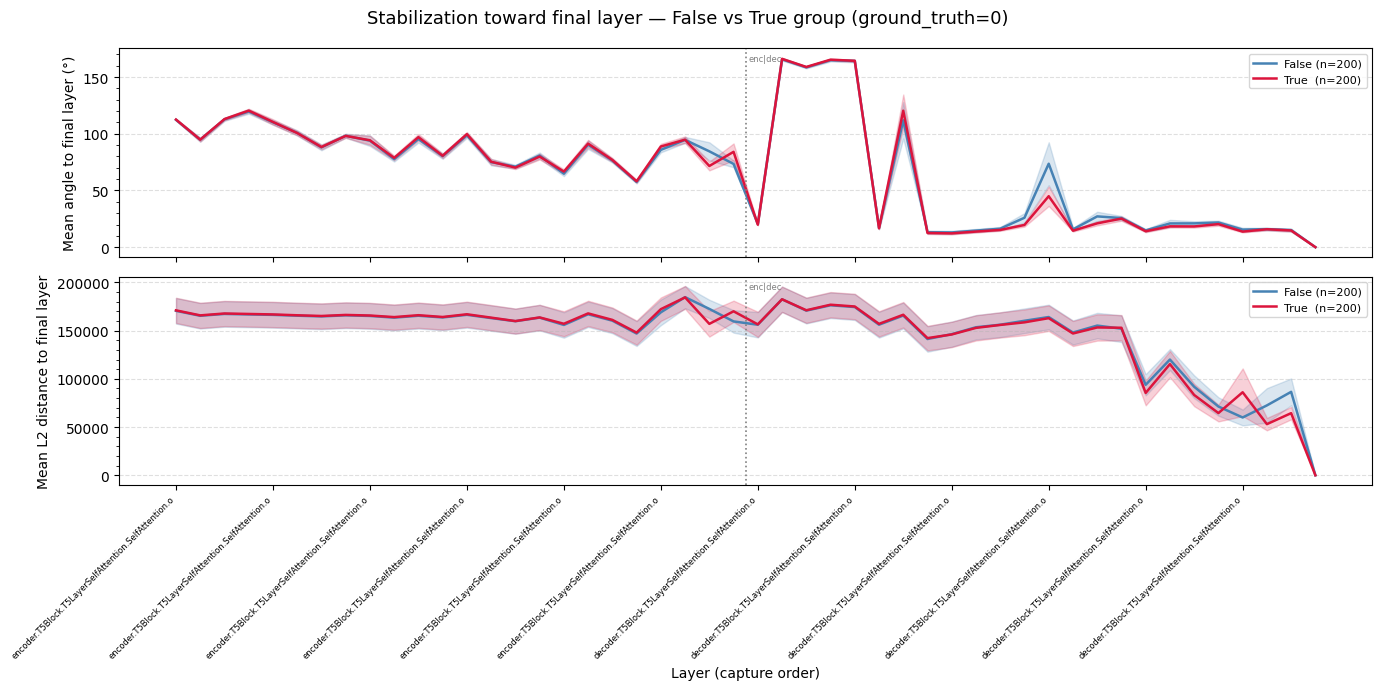

In [13]:
def _add_boundary(ax, boundary):
    if boundary is not None:
        ax.axvline(boundary - 0.5, color="gray", linestyle=":", linewidth=1.2)
        ylim = ax.get_ylim()
        ax.text(boundary - 0.4, ylim[1] * 0.97, "enc|dec",
                fontsize=6, color="gray", va="top")

def _set_xticks(ax, x, labels):
    step = max(1, len(x) // 10)
    ax.set_xticks(x[::step])
    ax.set_xticklabels(labels[::step], rotation=45, ha="right", fontsize=6)

def plot_group_comparison(title, x, labels, boundary,
                          metrics_false, metrics_true,
                          n_false, n_true,
                          ylabel_angle, ylabel_l2):
    """
    metrics_false / metrics_true: (mean_angles, std_angles, mean_l2s, std_l2s)
    each array has shape (len(x),).
    """
    ma_f, sa_f, ml_f, sl_f = metrics_false
    ma_t, sa_t, ml_t, sl_t = metrics_true

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(title, fontsize=13)

    # ── angle panel ────────────────────────────────────────────────────────
    ax1.plot(x, ma_f, color="steelblue", linewidth=1.8, label=f"False (n={n_false})")
    ax1.fill_between(x, ma_f - sa_f, ma_f + sa_f, alpha=0.2, color="steelblue")
    ax1.plot(x, ma_t, color="crimson",   linewidth=1.8, label=f"True  (n={n_true})")
    ax1.fill_between(x, ma_t - sa_t, ma_t + sa_t, alpha=0.2, color="crimson")
    ax1.set_ylabel(ylabel_angle)
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1.grid(axis="y", linestyle="--", alpha=0.4)
    ax1.legend(fontsize=8)
    _add_boundary(ax1, boundary)

    # ── L2 panel ────────────────────────────────────────────────────────────
    ax2.plot(x, ml_f, color="steelblue", linewidth=1.8, label=f"False (n={n_false})")
    ax2.fill_between(x, ml_f - sl_f, ml_f + sl_f, alpha=0.2, color="steelblue")
    ax2.plot(x, ml_t, color="crimson",   linewidth=1.8, label=f"True  (n={n_true})")
    ax2.fill_between(x, ml_t - sl_t, ml_t + sl_t, alpha=0.2, color="crimson")
    ax2.set_ylabel(ylabel_l2)
    ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax2.grid(axis="y", linestyle="--", alpha=0.4)
    ax2.legend(fontsize=8)
    _add_boundary(ax2, boundary)
    _set_xticks(ax2, x, labels)
    ax2.set_xlabel("Layer (capture order)")

    plt.tight_layout()
    plt.show()

# ── stabilization: angle/L2 to final layer ──────────────────────────────────
x_stab = np.arange(n_layers)
plot_group_comparison(
    title="Stabilization toward final layer — False vs True group (ground_truth=0)",
    x=x_stab, labels=layer_labels, boundary=boundary,
    metrics_false=stab_false, metrics_true=stab_true,
    n_false=len(lv_false), n_true=len(lv_true),
    ylabel_angle="Mean angle to final layer (°)",
    ylabel_l2="Mean L2 distance to final layer",
)

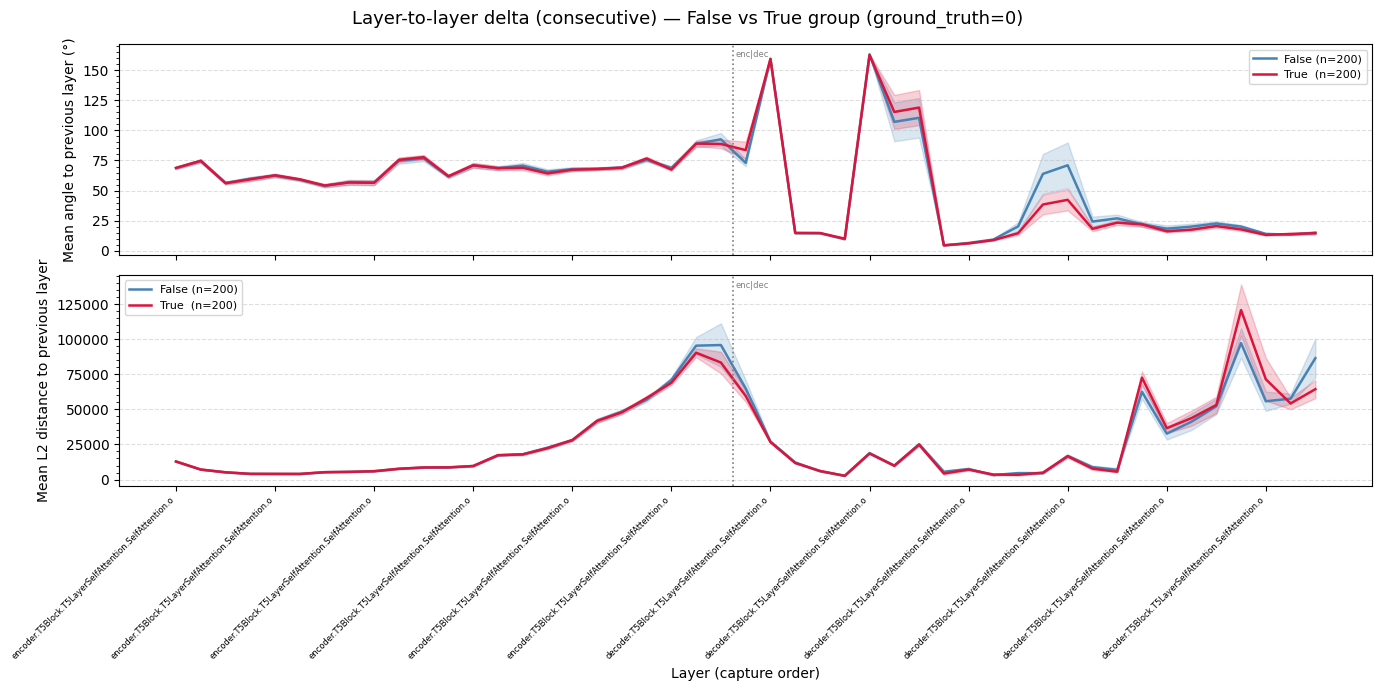

In [14]:
# ── consecutive delta: angle/L2 to previous layer ───────────────────────────
x_delta = np.arange(n_layers - 1)
delta_labels = layer_labels[1:]   # drop first label (no predecessor)
delta_boundary = boundary - 1 if boundary is not None else None

plot_group_comparison(
    title="Layer-to-layer delta (consecutive) — False vs True group (ground_truth=0)",
    x=x_delta, labels=delta_labels, boundary=delta_boundary,
    metrics_false=delta_false, metrics_true=delta_true,
    n_false=len(lv_false), n_true=len(lv_true),
    ylabel_angle="Mean angle to previous layer (°)",
    ylabel_l2="Mean L2 distance to previous layer",
)

---
## Last 10 layers zoom-in

Same four plots restricted to the final 10 `SelfAttention.o` layers, where the
model is closest to committing to its output token. Differences between the
False and True groups that are washed out across all layers may be more visible here.

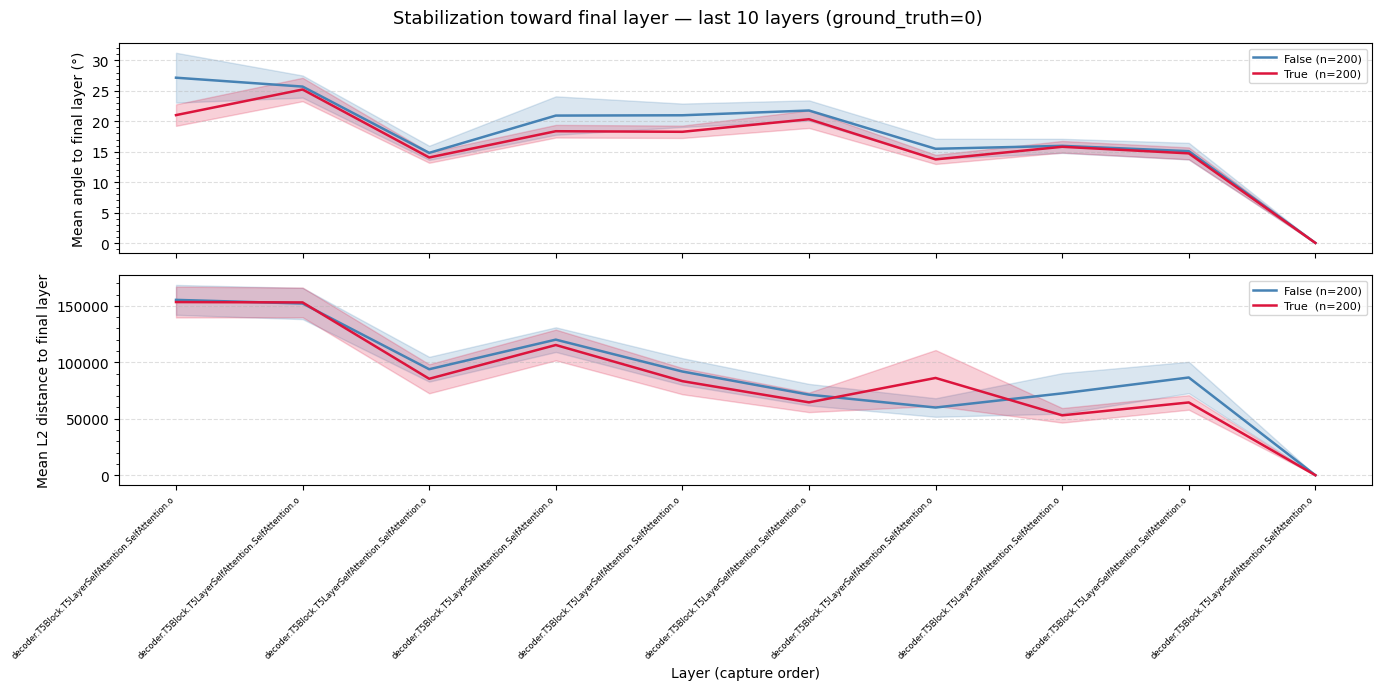

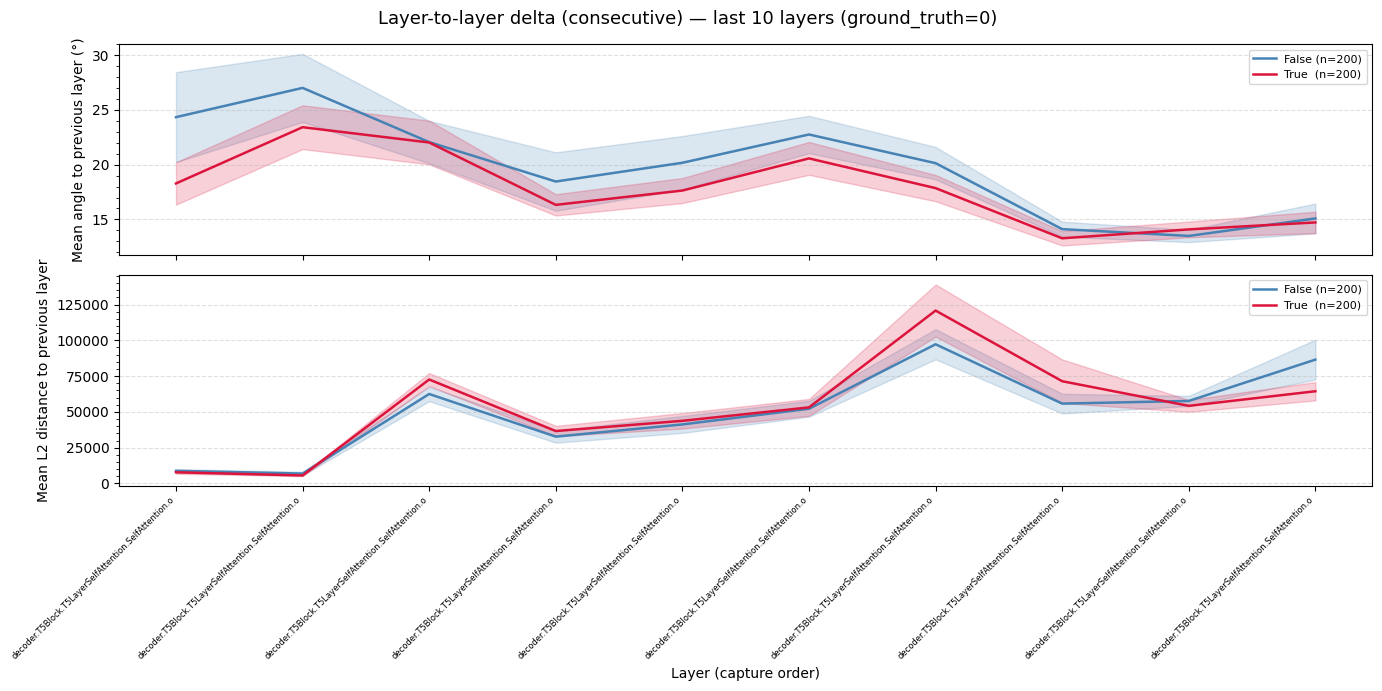

In [15]:
ZOOM = 10   # number of final layers to show

# ── slice helpers ────────────────────────────────────────────────────────────
def slice_metrics(metrics, start):
    """Slice all four arrays in a metrics tuple from index `start` onward."""
    return tuple(arr[start:] for arr in metrics)

stab_start  = n_layers - ZOOM
delta_start = (n_layers - 1) - ZOOM   # delta has n_layers-1 points

stab_false_z  = slice_metrics(stab_false,  stab_start)
stab_true_z   = slice_metrics(stab_true,   stab_start)
delta_false_z = slice_metrics(delta_false, delta_start)
delta_true_z  = slice_metrics(delta_true,  delta_start)

zoom_labels       = layer_labels[-ZOOM:]
zoom_delta_labels = layer_labels[1:][-ZOOM:]   # delta labels are layer_labels[1:]

x_stab_z  = np.arange(ZOOM)
x_delta_z = np.arange(ZOOM)

# Recalculate boundary position relative to the zoomed window (None if outside)
zoom_boundary = (boundary - stab_start) if (boundary is not None and boundary > stab_start) else None
zoom_delta_boundary = (boundary - 1 - delta_start) if (boundary is not None and (boundary - 1) > delta_start) else None

# ── stabilization (last 10 layers) ──────────────────────────────────────────
plot_group_comparison(
    title=f"Stabilization toward final layer — last {ZOOM} layers (ground_truth=0)",
    x=x_stab_z, labels=zoom_labels, boundary=zoom_boundary,
    metrics_false=stab_false_z, metrics_true=stab_true_z,
    n_false=len(lv_false), n_true=len(lv_true),
    ylabel_angle="Mean angle to final layer (°)",
    ylabel_l2="Mean L2 distance to final layer",
)

# ── consecutive delta (last 10 layers) ──────────────────────────────────────
plot_group_comparison(
    title=f"Layer-to-layer delta (consecutive) — last {ZOOM} layers (ground_truth=0)",
    x=x_delta_z, labels=zoom_delta_labels, boundary=zoom_delta_boundary,
    metrics_false=delta_false_z, metrics_true=delta_true_z,
    n_false=len(lv_false), n_true=len(lv_true),
    ylabel_angle="Mean angle to previous layer (°)",
    ylabel_l2="Mean L2 distance to previous layer",
)

---
## Cross-group divergence vs within-group cohesion

Each curve answers a different question about the logit vectors at layer *i*:

| Curve | What it measures |
|-------|-----------------|
| **Cross-group** (indigo solid) | Angle / L2 between the *mean* False vector and the *mean* True vector |
| **Within False** (steelblue dashed) | Mean pairwise angle / L2 *among* all False scans |
| **Within True** (crimson dotted) | Mean pairwise angle / L2 *among* all True scans |

**Interpretation key**
- cross > within-False and cross > within-True → the groups have *diverged*; the
  judge model is distinguishing between the two behaviours at that layer.
- cross ≈ within → both groups are equally spread out; no discriminative signal yet.
- Convergence at deep layers (cross → 0) means the judge converges on the same
  prediction regardless of ground-truth label.

In [16]:
def compute_divergence_metrics(lv_false, lv_true):
    """
    For each layer i, compute:
      - cross-group angle/L2 (mean_false vs mean_true)
      - within-False mean pairwise angle/L2
      - within-True  mean pairwise angle/L2

    Returns 6 np.arrays of shape (n_layers,):
      cross_angles, cross_l2s, wf_angles, wf_l2s, wt_angles, wt_l2s
    """
    n_layers = len(lv_false[0])

    cross_angles, cross_l2s = [], []
    wf_angles, wf_l2s = [], []
    wt_angles, wt_l2s = [], []

    for i in range(n_layers):
        # Stack into matrices: (N, vocab)
        F = torch.stack([lv[i]["logit_vector"].float() for lv in lv_false])  # (N_f, V)
        T = torch.stack([lv[i]["logit_vector"].float() for lv in lv_true])   # (N_t, V)

        # ── Cross-group: mean-vs-mean ──────────────────────────────────────
        mean_f = F.mean(dim=0)
        mean_t = T.mean(dim=0)
        cos_cross = torch.dot(mean_f, mean_t) / (mean_f.norm() * mean_t.norm())
        cross_angles.append(math.degrees(math.acos(cos_cross.clamp(-1, 1).item())))
        cross_l2s.append((mean_f - mean_t).norm().item())

        # ── Within-group pairwise ──────────────────────────────────────────
        def _within(M):
            N = M.shape[0]
            if N < 2:
                return 0.0, 0.0
            # Angles via normalised dot products
            M_norm = M / M.norm(dim=1, keepdim=True).clamp(min=1e-12)
            cos_mat = M_norm @ M_norm.T                      # (N, N)
            idx = torch.triu_indices(N, N, offset=1)         # upper-triangle pairs
            cos_vals = cos_mat[idx[0], idx[1]]
            angle = math.degrees(math.acos(cos_vals.clamp(-1, 1).float().mean().item()))
            # L2 via cdist
            l2_mat = torch.cdist(M.unsqueeze(0), M.unsqueeze(0)).squeeze(0)
            l2 = l2_mat[idx[0], idx[1]].mean().item()
            return angle, l2

        wf_a, wf_l = _within(F)
        wt_a, wt_l = _within(T)
        wf_angles.append(wf_a); wf_l2s.append(wf_l)
        wt_angles.append(wt_a); wt_l2s.append(wt_l)

    return (
        np.array(cross_angles), np.array(cross_l2s),
        np.array(wf_angles),    np.array(wf_l2s),
        np.array(wt_angles),    np.array(wt_l2s),
    )

divg_metrics = compute_divergence_metrics(lv_false, lv_true)
cross_angles, cross_l2s, wf_angles, wf_l2s, wt_angles, wt_l2s = divg_metrics

print(f"n_layers : {len(cross_angles)}")
print(f"NaN check: cross_angles={np.isnan(cross_angles).sum()}, "
      f"cross_l2s={np.isnan(cross_l2s).sum()}, "
      f"wf_angles={np.isnan(wf_angles).sum()}, "
      f"wt_angles={np.isnan(wt_angles).sum()}")
print(f"cross_angles range : [{cross_angles.min():.2f}, {cross_angles.max():.2f}] deg")
print(f"within-False range : [{wf_angles.min():.2f}, {wf_angles.max():.2f}] deg")
print(f"within-True  range : [{wt_angles.min():.2f}, {wt_angles.max():.2f}] deg")

n_layers : 48
NaN check: cross_angles=0, cross_l2s=0, wf_angles=0, wt_angles=0
cross_angles range : [0.00, 45.17] deg
within-False range : [0.00, 36.41] deg
within-True  range : [0.00, 26.46] deg


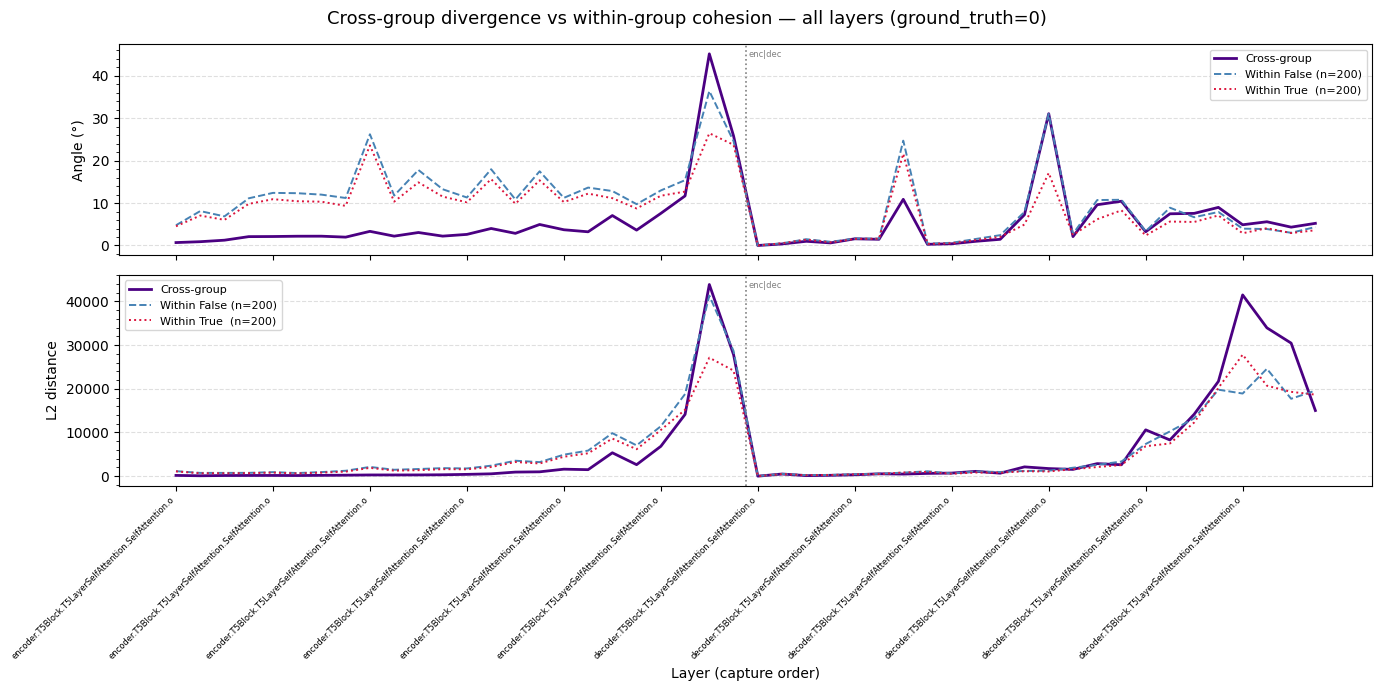

In [17]:
def plot_divergence(title, x, labels, boundary, metrics):
    """
    Two panels: angle (top) and L2 (bottom).
    Three curves per panel:
      - Cross-group   ─── indigo,    solid,  linewidth 2
      - Within False  --- steelblue, dashed, linewidth 1.4
      - Within True   ... crimson,   dotted, linewidth 1.4
    """
    ca, cl, wfa, wfl, wta, wtl = metrics

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    fig.suptitle(title, fontsize=13)

    # ── angle panel ──────────────────────────────────────────────────────
    ax1.plot(x, ca,  color="indigo",    linewidth=2,   linestyle="-",  label="Cross-group")
    ax1.plot(x, wfa, color="steelblue", linewidth=1.4, linestyle="--", label=f"Within False (n={len(lv_false)})")
    ax1.plot(x, wta, color="crimson",   linewidth=1.4, linestyle=":",  label=f"Within True  (n={len(lv_true)})")
    ax1.set_ylabel("Angle (°)")
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1.grid(axis="y", linestyle="--", alpha=0.4)
    ax1.legend(fontsize=8)
    _add_boundary(ax1, boundary)

    # ── L2 panel ─────────────────────────────────────────────────────────
    ax2.plot(x, cl,  color="indigo",    linewidth=2,   linestyle="-",  label="Cross-group")
    ax2.plot(x, wfl, color="steelblue", linewidth=1.4, linestyle="--", label=f"Within False (n={len(lv_false)})")
    ax2.plot(x, wtl, color="crimson",   linewidth=1.4, linestyle=":",  label=f"Within True  (n={len(lv_true)})")
    ax2.set_ylabel("L2 distance")
    ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax2.grid(axis="y", linestyle="--", alpha=0.4)
    ax2.legend(fontsize=8)
    _add_boundary(ax2, boundary)
    _set_xticks(ax2, x, labels)
    ax2.set_xlabel("Layer (capture order)")

    plt.tight_layout()
    plt.show()

plot_divergence(
    title="Cross-group divergence vs within-group cohesion — all layers (ground_truth=0)",
    x=np.arange(n_layers),
    labels=layer_labels,
    boundary=boundary,
    metrics=divg_metrics,
)

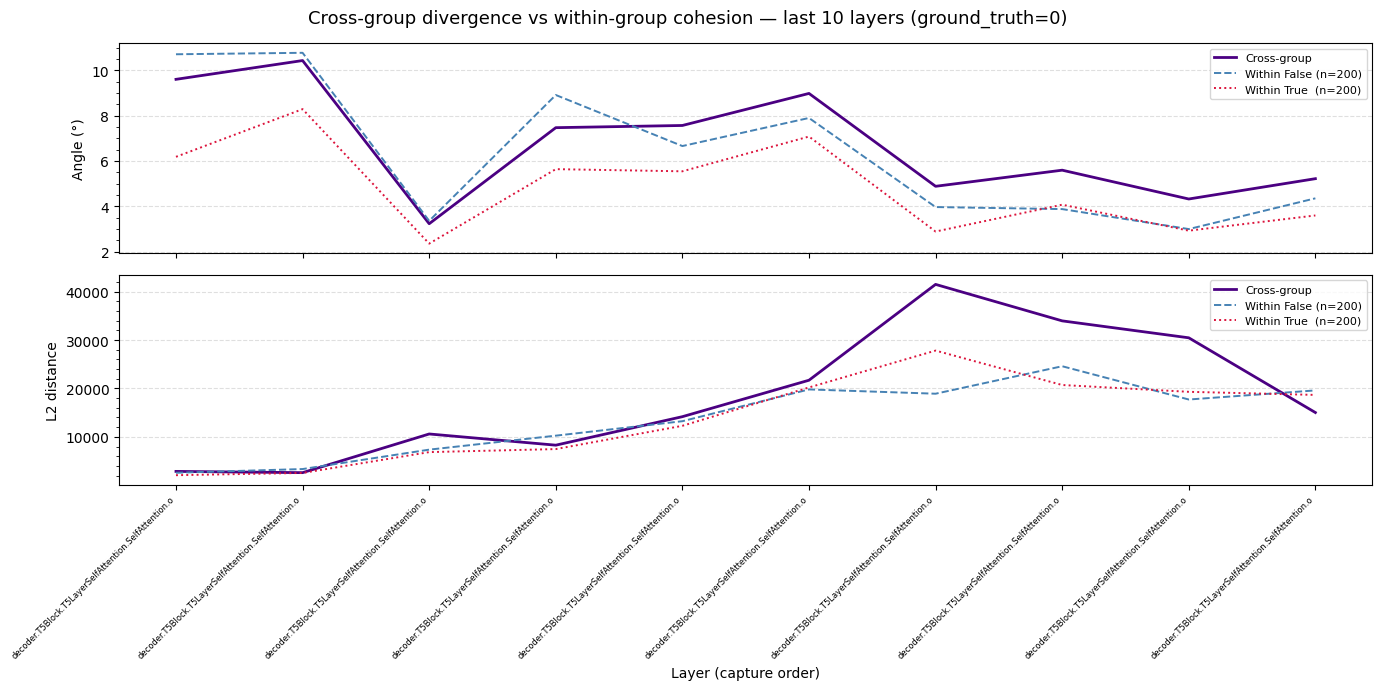

In [18]:
# ── last-ZOOM-layers zoom ───────────────────────────────────────────────────
divg_start = n_layers - ZOOM
divg_metrics_z = tuple(arr[divg_start:] for arr in divg_metrics)

plot_divergence(
    title=f"Cross-group divergence vs within-group cohesion — last {ZOOM} layers (ground_truth=0)",
    x=np.arange(ZOOM),
    labels=layer_labels[-ZOOM:],
    boundary=zoom_boundary,
    metrics=divg_metrics_z,
)

---
## Contextualising the distances: normalized L2, separation ratio (L2 and angle)

Three dimensionless metrics that make the raw numbers interpretable:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Normalized L2** | `cross_L2 / geometric_mean(‖mean_f‖, ‖mean_t‖)` | Fraction of average vector length. < 0.1 = tiny, ~0.5 = moderate, > 1 = far |
| **L2 separation ratio** | `cross_L2 / mean(within_False_L2, within_True_L2)` | How much more separated the groups are vs internal scatter. < 1 = no separation, > 2 = strong |
| **Angle separation ratio** | `cross_angle / mean(within_False_angle, within_True_angle)` | Same as above but for direction only. If this stays near 1 while L2 ratio peaks, the groups differ in **magnitude** not direction |

A reference line at **1.0** is drawn on each panel.

In [21]:
def compute_context_metrics(lv_false, lv_true, cross_l2s, wf_l2s, wt_l2s,
                             cross_angles, wf_angles, wt_angles):
    """
    Compute per-layer normalized L2, L2 separation ratio, and angle separation ratio.
    Reuses already-computed arrays from divg_metrics.
    """
    n_layers = len(lv_false[0])
    geo_mean_norms = []

    for i in range(n_layers):
        F = torch.stack([lv[i]["logit_vector"].float() for lv in lv_false])
        T = torch.stack([lv[i]["logit_vector"].float() for lv in lv_true])
        nf = F.mean(dim=0).norm().item()
        nt = T.mean(dim=0).norm().item()
        geo_mean_norms.append((nf * nt) ** 0.5)

    geo_mean_norms    = np.array(geo_mean_norms)
    normalized_l2     = cross_l2s    / np.maximum(geo_mean_norms, 1e-12)
    within_mean_l2    = (wf_l2s    + wt_l2s)    / 2
    within_mean_angle = (wf_angles + wt_angles) / 2
    separation_l2     = cross_l2s    / np.maximum(within_mean_l2,    1e-12)
    separation_angle  = cross_angles / np.maximum(within_mean_angle, 1e-12)

    return normalized_l2, separation_l2, separation_angle, geo_mean_norms

normalized_l2, separation_l2, separation_angle, geo_mean_norms = compute_context_metrics(
    lv_false, lv_true,
    cross_l2s, wf_l2s, wt_l2s,
    cross_angles, wf_angles, wt_angles,
)

print(f"Last layer — raw cross L2           : {cross_l2s[-1]:>10.1f}")
print(f"Last layer — mean vector norm       : {geo_mean_norms[-1]:>10.1f}")
print(f"Last layer — normalized L2          : {normalized_l2[-1]:>10.4f}  (fraction of vector length)")
print(f"Last layer — L2 separation ratio    : {separation_l2[-1]:>10.4f}  (cross / within-group L2)")
print(f"Last layer — angle separation ratio : {separation_angle[-1]:>10.4f}  (cross / within-group angle)")

Last layer — raw cross L2           :    15021.8
Last layer — mean vector norm       :   164885.3
Last layer — normalized L2          :     0.0911  (fraction of vector length)
Last layer — L2 separation ratio    :     0.7853  (cross / within-group L2)
Last layer — angle separation ratio :     1.3134  (cross / within-group angle)


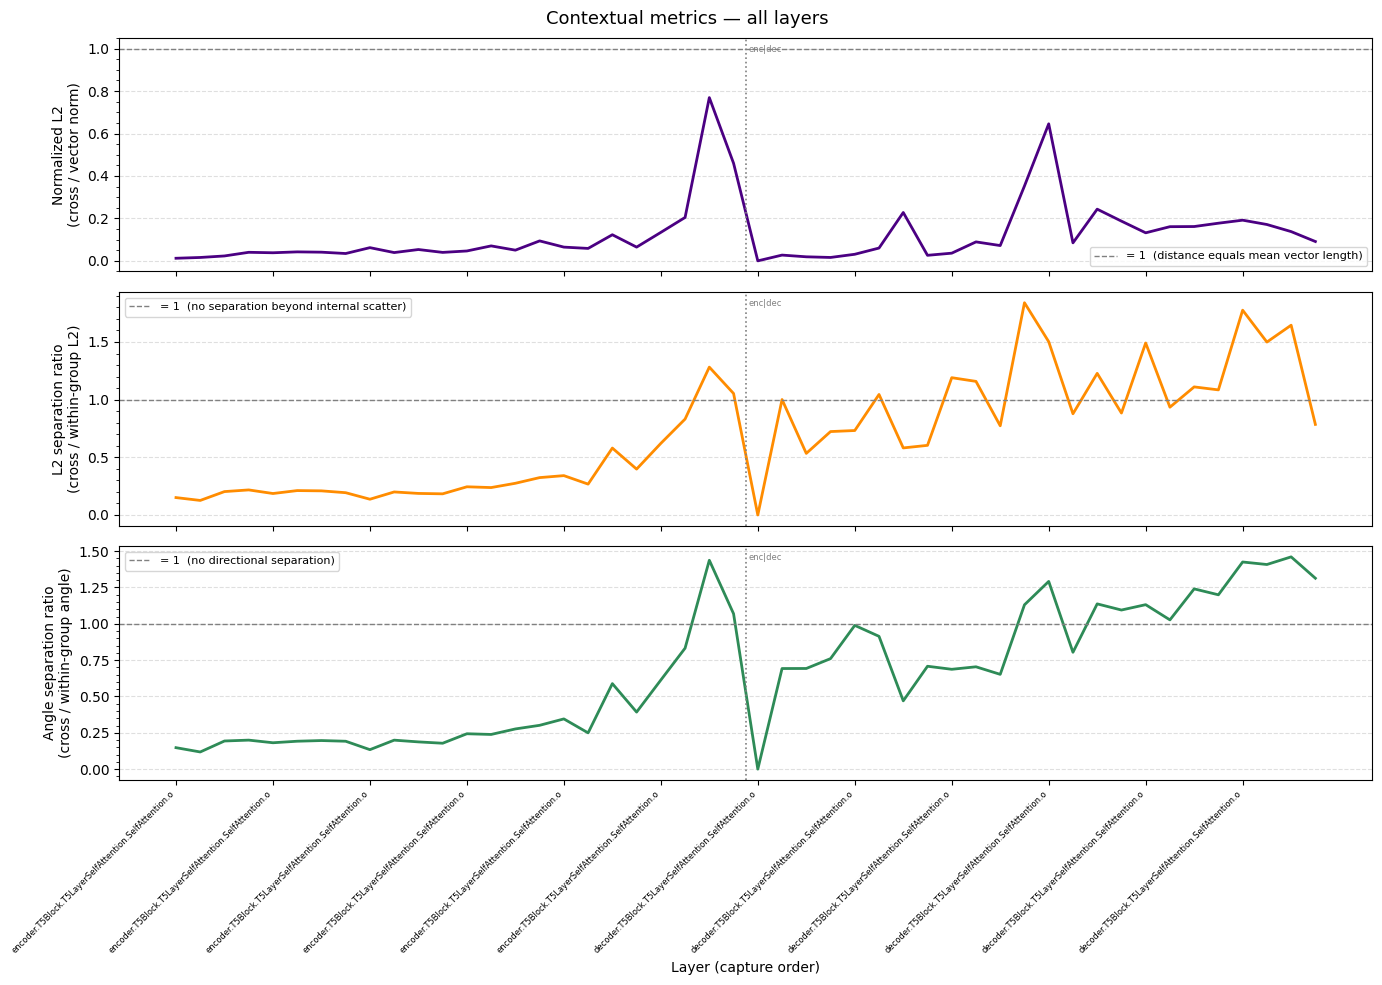

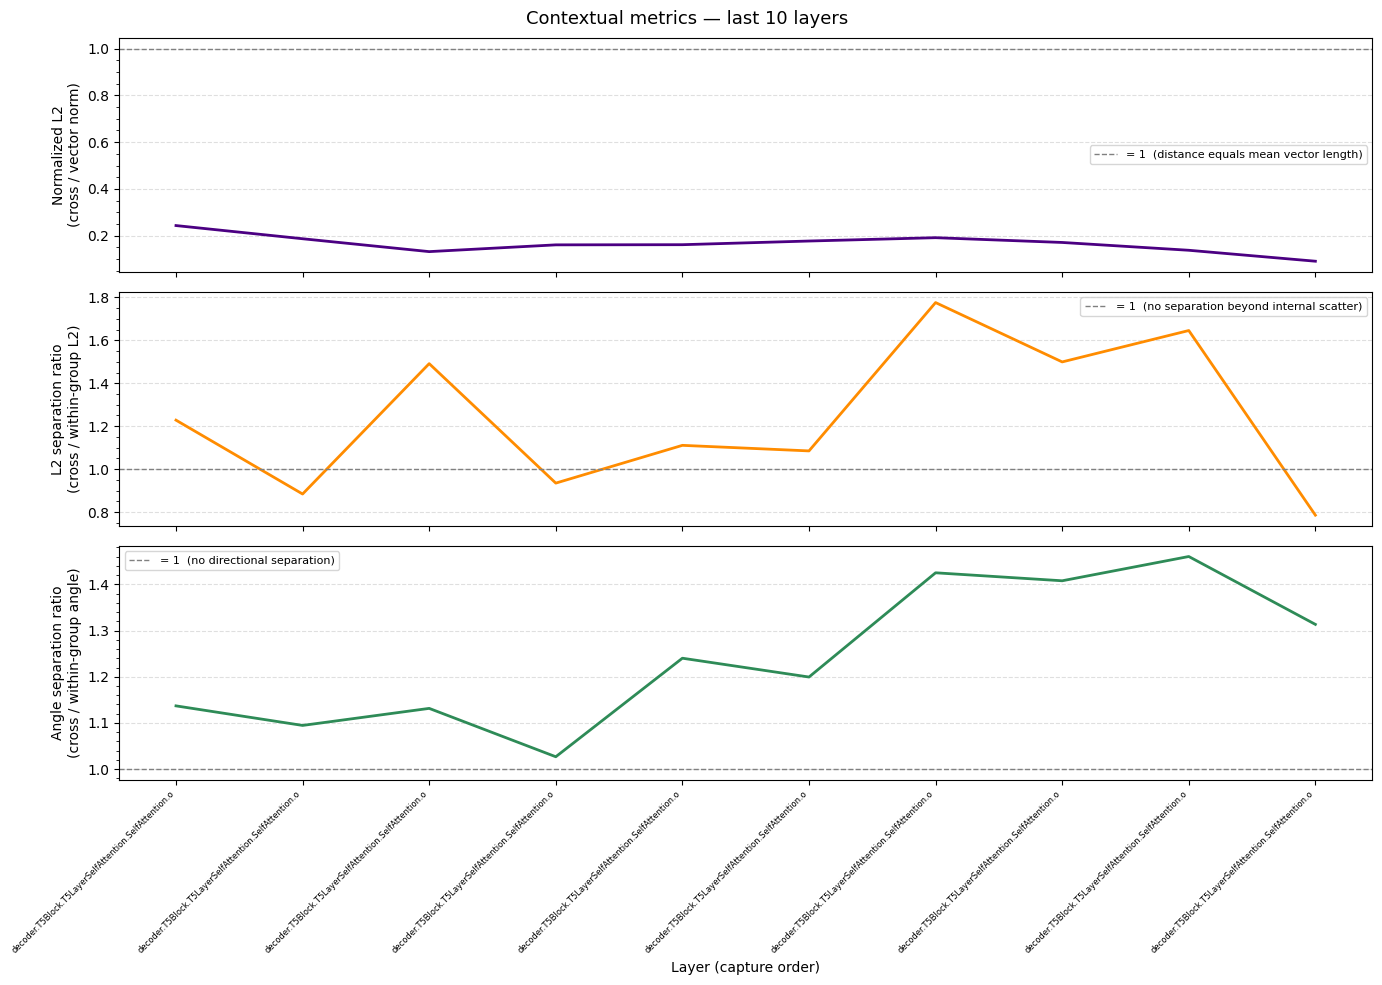

In [22]:
def plot_context_metrics(title_suffix, x, labels, boundary, norm_l2, sep_l2, sep_angle):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Contextual metrics — {title_suffix}", fontsize=13)

    # ── normalized L2 ────────────────────────────────────────────────────
    ax1.plot(x, norm_l2, color="indigo", linewidth=2)
    ax1.axhline(1.0, color="gray", linestyle="--", linewidth=1,
                label="= 1  (distance equals mean vector length)")
    ax1.set_ylabel("Normalized L2\n(cross / vector norm)")
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax1.grid(axis="y", linestyle="--", alpha=0.4)
    ax1.legend(fontsize=8)
    _add_boundary(ax1, boundary)

    # ── L2 separation ratio ──────────────────────────────────────────────
    ax2.plot(x, sep_l2, color="darkorange", linewidth=2)
    ax2.axhline(1.0, color="gray", linestyle="--", linewidth=1,
                label="= 1  (no separation beyond internal scatter)")
    ax2.set_ylabel("L2 separation ratio\n(cross / within-group L2)")
    ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax2.grid(axis="y", linestyle="--", alpha=0.4)
    ax2.legend(fontsize=8)
    _add_boundary(ax2, boundary)

    # ── angle separation ratio ───────────────────────────────────────────
    ax3.plot(x, sep_angle, color="seagreen", linewidth=2)
    ax3.axhline(1.0, color="gray", linestyle="--", linewidth=1,
                label="= 1  (no directional separation)")
    ax3.set_ylabel("Angle separation ratio\n(cross / within-group angle)")
    ax3.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax3.grid(axis="y", linestyle="--", alpha=0.4)
    ax3.legend(fontsize=8)
    _add_boundary(ax3, boundary)
    _set_xticks(ax3, x, labels)
    ax3.set_xlabel("Layer (capture order)")

    plt.tight_layout()
    plt.show()

# ── all layers ───────────────────────────────────────────────────────────────
plot_context_metrics(
    "all layers",
    x=np.arange(n_layers), labels=layer_labels, boundary=boundary,
    norm_l2=normalized_l2, sep_l2=separation_l2, sep_angle=separation_angle,
)

# ── last ZOOM layers ─────────────────────────────────────────────────────────
plot_context_metrics(
    f"last {ZOOM} layers",
    x=np.arange(ZOOM), labels=layer_labels[-ZOOM:], boundary=zoom_boundary,
    norm_l2=normalized_l2[-ZOOM:], sep_l2=separation_l2[-ZOOM:],
    sep_angle=separation_angle[-ZOOM:],
)